# Confronto — baselines vs fusion (all models)

Loads **every** `results/*.json` and builds the comparison for the presentation. Reads only from disk. Train each model in `training.ipynb` (+ Pipeline D §8b) first.

## 0. Load every saved run

In [1]:
# Repo-root bootstrap — lets this notebook run from notebooks/ or the repo root.
import os, sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "globals.py").exists())
os.chdir(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("repo root:", _ROOT)

repo root: /home/leonardo/Desktop/AIRO/stereo-lidar-perception


In [2]:
import os, json
from pathlib import Path
import data  # noqa: F401
_REPO = Path(data.__file__).resolve().parent
os.environ.setdefault("PY123D_DATA_ROOT", str(_REPO / "data"))
os.environ.setdefault("KITTI360_DATA_ROOT", str(_REPO / "KITTI-360"))
import numpy as np
import matplotlib.pyplot as plt
import globals as G
from evaluation import load_report, compare_reports
FIGDIR = Path("docs/img"); FIGDIR.mkdir(parents=True, exist_ok=True)
ORDER = [("lidar","LiDAR-only"), ("camera_yolo26_igev","Camera-only"),
         ("pipeline_d","D · late fusion"), ("pipeline_a_yolo26_igev","A · concat-conv"),
         ("pipeline_b_yolo26_igev","B · painted"), ("pipeline_c_yolo26_igev","C · cross-attn")]
reports = {}
for stem, label in ORDER:
    p = Path("results") / f"{stem}.json"
    if p.exists(): reports[label] = load_report(p)
missing = [s for s, _ in ORDER if not (Path("results") / f"{s}.json").exists()]
print("loaded:", list(reports))
if missing: print("missing (train first):", missing)

/home/leonardo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


loaded: ['LiDAR-only', 'Camera-only', 'D · late fusion', 'A · concat-conv']
missing (train first): ['pipeline_b_yolo26_igev', 'pipeline_c_yolo26_igev']


## 1. Comparison table

In [3]:
compare_reports(reports)

model             VEHICLE    PERSON     TWO_WHEELE TRAFFIC_SI TRAIN      mAP    P      R      F1     err(m)
-----------------------------------------------------------------------------------------------------------
LiDAR-only        0.543      0.156      0.140      0.269      0.000      0.222  0.314  0.274  0.286  0.468
Camera-only       0.424      0.159      0.131      0.067      0.000      0.156  0.316  0.241  0.271  0.610
D · late fusion   0.601      0.239      0.194      0.264      0.000      0.260  0.370  0.303  0.327  0.483
A · concat-conv   0.721      0.476      0.386      0.290      0.000      0.374  0.426  0.384  0.403  0.345


## 2. Per-class AP by model

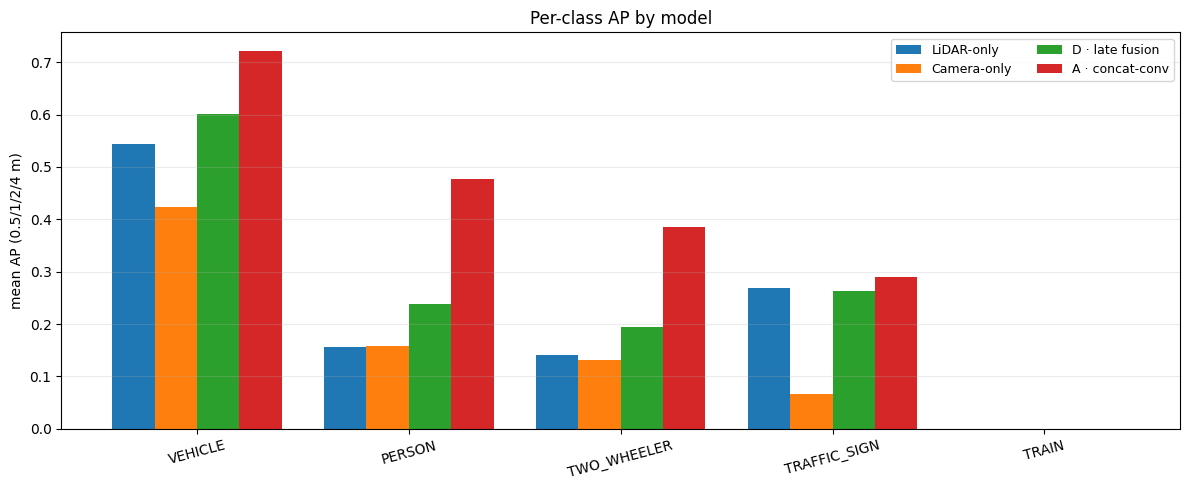

In [4]:
classes = [c for c in G.CLASSES if any(r["per_class"][c]["n_gt"] for r in reports.values())]
models = list(reports); x = np.arange(len(classes)); w = 0.8 / max(1, len(models))
fig, ax = plt.subplots(figsize=(1.6 * len(classes) + 4, 5))
for i, m in enumerate(models):
    vals = [reports[m]["per_class"][c]["mean"] if reports[m]["per_class"][c]["n_gt"] else 0.0 for c in classes]
    ax.bar(x + i * w, vals, w, label=m)
ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(classes, rotation=15)
ax.set_ylabel("mean AP (0.5/1/2/4 m)"); ax.set_title("Per-class AP by model")
ax.legend(ncol=2, fontsize=9); ax.grid(axis="y", alpha=0.25)
fig.tight_layout(); fig.savefig(FIGDIR / "compare_per_class_ap.png", dpi=100, bbox_inches="tight"); plt.show()

## 3. Overall mAP + fusion gain

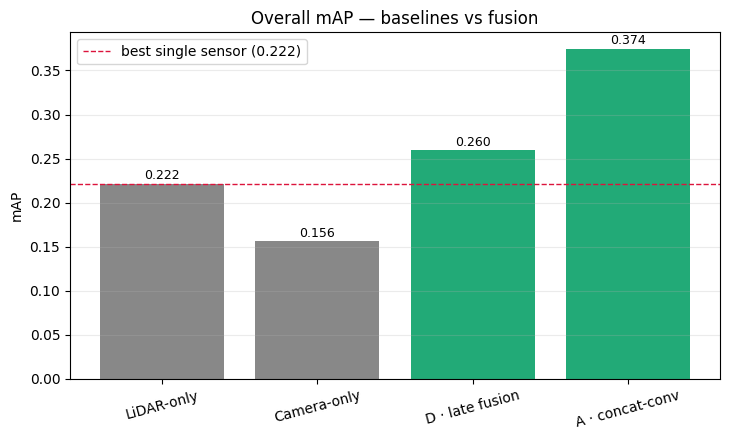

Fusion gain over best single sensor (mAP):
  D · late fusion    +0.038
  A · concat-conv    +0.153


In [5]:
models = list(reports); maps = {m: reports[m]["mAP"] for m in models}
base = max(maps.get("LiDAR-only", float("nan")), maps.get("Camera-only", float("nan")))
fig, ax = plt.subplots(figsize=(1.1 * len(models) + 3, 4.5))
colors = ["#888" if m in ("LiDAR-only", "Camera-only") else "#2a7" for m in models]
bars = ax.bar(models, [maps[m] for m in models], color=colors)
if np.isfinite(base):
    ax.axhline(base, ls="--", color="crimson", lw=1, label=f"best single sensor ({base:.3f})"); ax.legend()
for b, m in zip(bars, models):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, f"{maps[m]:.3f}", ha="center", fontsize=9)
ax.set_ylabel("mAP"); ax.set_title("Overall mAP — baselines vs fusion")
ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.25)
fig.tight_layout(); fig.savefig(FIGDIR / "compare_map.png", dpi=100, bbox_inches="tight"); plt.show()
print("Fusion gain over best single sensor (mAP):")
for m in models:
    if m not in ("LiDAR-only", "Camera-only") and np.isfinite(base):
        print(f"  {m:<18} {maps[m]-base:+.3f}")

## 4. Validation-loss curves

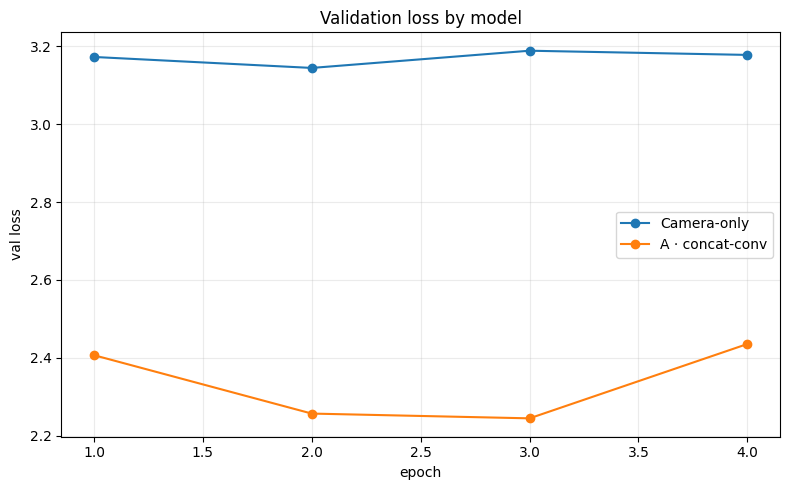

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for stem, label in ORDER:
    h = Path("results") / f"{stem}_history.json"
    if h.exists():
        val = json.loads(h.read_text()).get("val", [])
        if val: ax.plot(range(1, len(val) + 1), val, "o-", label=label)
ax.set_xlabel("epoch"); ax.set_ylabel("val loss"); ax.set_title("Validation loss by model")
ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIGDIR / "compare_val_loss.png", dpi=100, bbox_inches="tight"); plt.show()

---
*Per-model detail: the individual notebooks.*